# Stack Overflow 2024 Developer Survey — Data Cleaning

This notebook walks through cleaning the raw Stack Overflow 2024 Developer Survey data into a form
ready for analysis: removing duplicates, handling missing values, normalizing skewed numeric columns,
and engineering a couple of new features.

The next notebook (`02_eda_and_insights.ipynb`) builds on this cleaned dataset to run the actual
exploratory analysis and pull out insights.

**Data source**: [Stack Overflow Developer Survey 2024](https://survey.stackoverflow.co/2024/)


## 0. Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option('display.max_columns', None)

## 1. Load the Data

Load the survey data and take a first look at its structure.

In [2]:
dataset_url = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/n01PQ9pSmiRX6520flujwQ/survey-data.csv"
df = pd.read_csv(dataset_url)
df.head()

,ResponseId,MainBranch,Age,Employment,RemoteWork,Check,CodingActivities,EdLevel,LearnCode,LearnCodeOnline,TechDoc,YearsCode,YearsCodePro,DevType,OrgSize,PurchaseInfluence,BuyNewTool,BuildvsBuy,TechEndorse,Country,Currency,CompTotal,LanguageHaveWorkedWith,LanguageWantToWorkWith,LanguageAdmired,DatabaseHaveWorkedWith,DatabaseWantToWorkWith,DatabaseAdmired,PlatformHaveWorkedWith,PlatformWantToWorkWith,PlatformAdmired,WebframeHaveWorkedWith,WebframeWantToWorkWith,WebframeAdmired,EmbeddedHaveWorkedWith,EmbeddedWantToWorkWith,EmbeddedAdmired,MiscTechHaveWorkedWith,MiscTechWantToWorkWith,MiscTechAdmired,ToolsTechHaveWorkedWith,ToolsTechWantToWorkWith,ToolsTechAdmired,NEWCollabToolsHaveWorkedWith,NEWCollabToolsWantToWorkWith,NEWCollabToolsAdmired,OpSysPersonal use,OpSysProfessional use,OfficeStackAsyncHaveWorkedWith,OfficeStackAsyncWantToWorkWith,OfficeStackAsyncAdmired,OfficeStackSyncHaveWorkedWith,OfficeStackSyncWantToWorkWith,OfficeStackSyncAdmired,AISearchDevHaveWorkedWith,AISearchDevWantToWorkWith,AISearchDevAdmired,NEWSOSites,SOVisitFreq,SOAccount,SOPartFreq,SOHow,SOComm,AISelect,AISent,AIBen,AIAcc,AIComplex,AIToolCurrently Using,AIToolInterested in Using,AIToolNot interested in Using,AINextMuch more integrated,AINextNo change,AINextMore integrated,AINextLess integrated,AINextMuch less integrated,AIThreat,AIEthics,AIChallenges,TBranch,ICorPM,WorkExp,Knowledge_1,Knowledge_2,Knowledge_3,Knowledge_4,Knowledge_5,Knowledge_6,Knowledge_7,Knowledge_8,Knowledge_9,Frequency_1,Frequency_2,Frequency_3,TimeSearching,TimeAnswering,Frustration,ProfessionalTech,ProfessionalCloud,ProfessionalQuestion,Industry,JobSatPoints_1,JobSatPoints_4,JobSatPoints_5,JobSatPoints_6,JobSatPoints_7,JobSatPoints_8,JobSatPoints_9,JobSatPoints_10,JobSatPoints_11,SurveyLength,SurveyEase,ConvertedCompYearly,JobSat
0,1,I am a developer by profession,Under 18 years old,"Employed, full-time",Remote,Apples,Hobby,Primary/elementary school,Books / Physical media,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,United States of America,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,I have never visited Stack Overflow or the Sta...,NaN,NaN,NaN,NaN,NaN,Yes,Very favorable,Increase productivity,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,No,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2,I am a developer by profession,35-44 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,API document(s) and/or SDK document(s);User gu...,20,17,"Developer, full-stack",NaN,NaN,NaN,NaN,NaN,United Kingdom of Great Britain and Northern I...,NaN,NaN,Bash/Shell (all shells);Go;HTML/CSS;Java;JavaS...,Bash/Shell (all shells);Go;HTML/CSS;Java;JavaS...,Bash/Shell (all shells);Go;HTML/CSS;Java;JavaS...,Dynamodb;MongoDB;PostgreSQL,PostgreSQL,PostgreSQL,Amazon Web Services (AWS);Heroku;Netlify,Amazon Web Services (AWS);Heroku;Netlify,Amazon Web Services (AWS);Heroku;Netlify,Express;Next.js;Node.js;React,Express;Htmx;Node.js;React;Remix,Express;Node.js;React,NaN,NaN,NaN,NaN,NaN,NaN,Docker;Homebrew;Kubernetes;npm;Vite;Webpack,Docker;Homebrew;Kubernetes;npm;Vite;Webpack,Docker;Homebrew;Kubernetes;npm;Vite;Webpack,PyCharm;Visual Studio Code;WebStorm,PyCharm;Visual Studio Code;WebStorm,PyCharm;Visual Studio Code;WebStorm,MacOS;Windows,MacOS,NaN,NaN,NaN,Microsoft Teams;Slack,Slack,Slack,NaN,NaN,NaN,Stack Overflow for Teams (private knowledge sh...,Multiple times per day,Yes,Multiple times per day,Quickly finding code solutions;Finding reliabl...,"Yes, definitely","No, and I don't plan to",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Yes,Individual contributor,17.0,Agree,Disagree,Agree,Agree,Agree,Neither agree nor disa

In [3]:
print('-------info()-------')
print(df.info())
print('-------dtypes-------')
print(df.dtypes)
print('-------null values-------')
print(df.isnull().sum())

-------info()-------
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 65437 entries, 0 to 65436
Columns: 114 entries, ResponseId to JobSat
dtypes: float64(13), int64(1), object(100)
memory usage: 56.9+ MB
None
-------dtypes-------
ResponseId               int64
MainBranch              object
Age                     object
Employment              object
RemoteWork              object
                        ...   
JobSatPoints_11        float64
SurveyLength            object
SurveyEase              object
ConvertedCompYearly    float64
JobSat                 float64
Length: 114, dtype: object
-------null values-------
ResponseId                 0
MainBranch                 0
Age                        0
Employment                 0
RemoteWork             10631
                       ...  
JobSatPoints_11        35992
SurveyLength            9255
SurveyEase              9199
ConvertedCompYearly    42002
JobSat                 36311
Length: 114, dtype: int64


In [4]:
df.describe()

,ResponseId,CompTotal,WorkExp,JobSatPoints_1,JobSatPoints_4,JobSatPoints_5,JobSatPoints_6,JobSatPoints_7,JobSatPoints_8,JobSatPoints_9,JobSatPoints_10,JobSatPoints_11,ConvertedCompYearly,JobSat
count,65437.000000,3.374000e+04,29658.000000,29324.000000,29393.000000,29411.000000,29450.000000,29448.00000,29456.000000,29456.000000,29450.000000,29445.000000,2.343500e+04,29126.000000
mean,32719.000000,2.963841e+145,11.466957,18.581094,7.522140,10.060857,24.343232,22.96522,20.278165,16.169432,10.955713,9.953948,8.615529e+04,6.935041
std,18890.179119,5.444117e+147,9.168709,25.966221,18.422661,21.833836,27.089360,27.01774,26.108110,24.845032,22.906263,21.775652,1.867570e+05,2.088259
min,1.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,1.000000e+00,0.000000
25%,16360.000000,6.000000e+04,4.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,3.271200e+04,6.000000
50%,32719.000000,1.100000e+05,9.000000,10.000000,0.000000,0.000000,20.000000,15.00000,10.000000,5.000000,0.000000,0.000000,6.500000e+04,7.000000
75%,49078.000000,2.500000e+05,16.000000,22.000000,5.000000,10.000000,30.000000,30.00000,25.000000,20.000000,10.000000,10.000000,1.079715e+05,8.000000
max,65437.000000,1.000000e+150,50.000000,100.000000,100.000000,100.000000,100.000000,100.00000,100.000000,100.000000,100.000000,100.000000,1.625660e+07,10.000000


## 2. Handling Duplicates

Survey data can contain duplicate rows, but blindly dropping anything `duplicated()` flags is risky.
If duplicates are judged only on response-pattern columns (`MainBranch`, `Employment`, `RemoteWork`, etc.)
instead of a column that is actually unique per respondent (`ResponseId`), legitimate respondents who
simply answered the same way could get removed by mistake.

I first checked exact full-row duplicates, then separately inspected rows that only matched on a
subset of columns to judge whether those were genuinely duplicate responses.

In [5]:
duplicate_rows_count = df.duplicated().sum()
print(f"Exact duplicate rows: {duplicate_rows_count}")
df[df.duplicated()].head()

Exact duplicate rows: 0


,ResponseId,MainBranch,Age,Employment,RemoteWork,Check,CodingActivities,EdLevel,LearnCode,LearnCodeOnline,TechDoc,YearsCode,YearsCodePro,DevType,OrgSize,PurchaseInfluence,BuyNewTool,BuildvsBuy,TechEndorse,Country,Currency,CompTotal,LanguageHaveWorkedWith,LanguageWantToWorkWith,LanguageAdmired,DatabaseHaveWorkedWith,DatabaseWantToWorkWith,DatabaseAdmired,PlatformHaveWorkedWith,PlatformWantToWorkWith,PlatformAdmired,WebframeHaveWorkedWith,WebframeWantToWorkWith,WebframeAdmired,EmbeddedHaveWorkedWith,EmbeddedWantToWorkWith,EmbeddedAdmired,MiscTechHaveWorkedWith,MiscTechWantToWorkWith,MiscTechAdmired,ToolsTechHaveWorkedWith,ToolsTechWantToWorkWith,ToolsTechAdmired,NEWCollabToolsHaveWorkedWith,NEWCollabToolsWantToWorkWith,NEWCollabToolsAdmired,OpSysPersonal use,OpSysProfessional use,OfficeStackAsyncHaveWorkedWith,OfficeStackAsyncWantToWorkWith,OfficeStackAsyncAdmired,OfficeStackSyncHaveWorkedWith,OfficeStackSyncWantToWorkWith,OfficeStackSyncAdmired,AISearchDevHaveWorkedWith,AISearchDevWantToWorkWith,AISearchDevAdmired,NEWSOSites,SOVisitFreq,SOAccount,SOPartFreq,SOHow,SOComm,AISelect,AISent,AIBen,AIAcc,AIComplex,AIToolCurrently Using,AIToolInterested in Using,AIToolNot interested in Using,AINextMuch more integrated,AINextNo change,AINextMore integrated,AINextLess integrated,AINextMuch less integrated,AIThreat,AIEthics,AIChallenges,TBranch,ICorPM,WorkExp,Knowledge_1,Knowledge_2,Knowledge_3,Knowledge_4,Knowledge_5,Knowledge_6,Knowledge_7,Knowledge_8,Knowledge_9,Frequency_1,Frequency_2,Frequency_3,TimeSearching,TimeAnswering,Frustration,ProfessionalTech,ProfessionalCloud,ProfessionalQuestion,Industry,JobSatPoints_1,JobSatPoints_4,JobSatPoints_5,JobSatPoints_6,JobSatPoints_7,JobSatPoints_8,JobSatPoints_9,JobSatPoints_10,JobSatPoints_11,SurveyLength,SurveyEase,ConvertedCompYearly,JobSat


In [6]:
# Rows that match only on a subset of response columns (ResponseId differs) -
# checking whether these are genuinely the same respondent or just similar answers
df[df.duplicated(keep=False)].sort_values(by='ResponseId')

,ResponseId,MainBranch,Age,Employment,RemoteWork,Check,CodingActivities,EdLevel,LearnCode,LearnCodeOnline,TechDoc,YearsCode,YearsCodePro,DevType,OrgSize,PurchaseInfluence,BuyNewTool,BuildvsBuy,TechEndorse,Country,Currency,CompTotal,LanguageHaveWorkedWith,LanguageWantToWorkWith,LanguageAdmired,DatabaseHaveWorkedWith,DatabaseWantToWorkWith,DatabaseAdmired,PlatformHaveWorkedWith,PlatformWantToWorkWith,PlatformAdmired,WebframeHaveWorkedWith,WebframeWantToWorkWith,WebframeAdmired,EmbeddedHaveWorkedWith,EmbeddedWantToWorkWith,EmbeddedAdmired,MiscTechHaveWorkedWith,MiscTechWantToWorkWith,MiscTechAdmired,ToolsTechHaveWorkedWith,ToolsTechWantToWorkWith,ToolsTechAdmired,NEWCollabToolsHaveWorkedWith,NEWCollabToolsWantToWorkWith,NEWCollabToolsAdmired,OpSysPersonal use,OpSysProfessional use,OfficeStackAsyncHaveWorkedWith,OfficeStackAsyncWantToWorkWith,OfficeStackAsyncAdmired,OfficeStackSyncHaveWorkedWith,OfficeStackSyncWantToWorkWith,OfficeStackSyncAdmired,AISearchDevHaveWorkedWith,AISearchDevWantToWorkWith,AISearchDevAdmired,NEWSOSites,SOVisitFreq,SOAccount,SOPartFreq,SOHow,SOComm,AISelect,AISent,AIBen,AIAcc,AIComplex,AIToolCurrently Using,AIToolInterested in Using,AIToolNot interested in Using,AINextMuch more integrated,AINextNo change,AINextMore integrated,AINextLess integrated,AINextMuch less integrated,AIThreat,AIEthics,AIChallenges,TBranch,ICorPM,WorkExp,Knowledge_1,Knowledge_2,Knowledge_3,Knowledge_4,Knowledge_5,Knowledge_6,Knowledge_7,Knowledge_8,Knowledge_9,Frequency_1,Frequency_2,Frequency_3,TimeSearching,TimeAnswering,Frustration,ProfessionalTech,ProfessionalCloud,ProfessionalQuestion,Industry,JobSatPoints_1,JobSatPoints_4,JobSatPoints_5,JobSatPoints_6,JobSatPoints_7,JobSatPoints_8,JobSatPoints_9,JobSatPoints_10,JobSatPoints_11,SurveyLength,SurveyEase,ConvertedCompYearly,JobSat


**Decision rule**: `ResponseId` is assigned uniquely per respondent, so only rows that share the
same `ResponseId` should be treated as true duplicates and removed. The other columns are answer content,
so different people can legitimately give the same answers — using those alone to judge duplicates risks
losing valid respondents.

Removal process:
1. Use `duplicated(subset=[...], keep=False)` to flag candidate duplicates on specific columns
2. Sort by `ResponseId` to confirm whether the rows are actually identical
3. Remove with `drop_duplicates()`
4. Compare the shape before and after to verify the result

In [7]:
before = df.shape[0]
df = df.drop_duplicates()
after = df.shape[0]
print(f"Before: {before} rows -> After: {after} rows ({before - after} rows removed)")

Before: 65437 rows -> After: 65437 rows (0 rows removed)


## 3. Missing Values

I checked the proportion of missing values per column and applied a different imputation strategy
depending on what kind of column it was.

In [8]:
null_summary = df.isnull().sum().sort_values(ascending=False)
null_summary.head(15)

AINextMuch less integrated       64289
AINextLess integrated            63082
AINextNo change                  52939
AINextMuch more integrated       51999
EmbeddedAdmired                  48704
EmbeddedWantToWorkWith           47837
EmbeddedHaveWorkedWith           43223
ConvertedCompYearly              42002
AIToolNot interested in Using    41023
AINextMore integrated            41009
Knowledge_9                      37802
Frequency_3                      37727
Knowledge_8                      37679
ProfessionalTech                 37673
Knowledge_7                      37659
dtype: int64

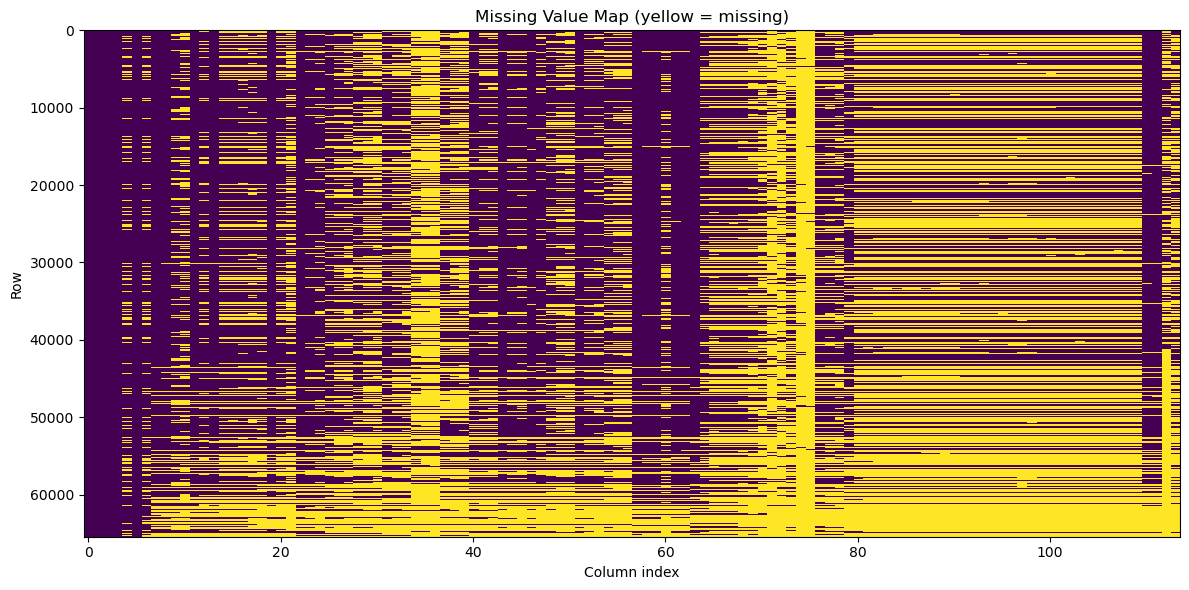

In [9]:
plt.figure(figsize=(12, 6))
plt.imshow(df.isnull(), aspect='auto', cmap='viridis', interpolation='none')
plt.title('Missing Value Map (yellow = missing)')
plt.xlabel('Column index')
plt.ylabel('Row')
plt.tight_layout()
plt.show()

### 3.1 Categorical Columns — Mode Imputation

For categorical columns like `Employment` and `RemoteWork`, missing values were filled with the
column's mode (most frequent value).

In [10]:
categorical_cols = df.select_dtypes(include='object').columns
for col in categorical_cols:
    if df[col].mode().empty:
        continue
    df[col] = df[col].fillna(df[col].mode()[0])

# Check what's left
df[categorical_cols].isnull().sum()[df[categorical_cols].isnull().sum() > 0]

Series([], dtype: int64)

### 3.2 Numeric Columns — Mean / Median Imputation

For a column like `CompTotal`, where the scale varies wildly by country, filling with the overall mean
didn't make sense — I used the **per-country median** instead. For the same reason, job satisfaction
scores (`JobSatPoints_*`) and work experience (`WorkExp`) were filled with their column mean.

**Important**: before filling, I flag which rows were originally missing. A large share of
`ConvertedCompYearly` turned out to be missing, so simply filling it with the median and moving on
would mean a single repeated value dominates the column — which would distort any later distribution,
outlier, or group-comparison analysis. The flag lets later notebooks exclude these imputed rows from
analyses where a real reported value matters, while still keeping them in the dataset for analyses
where they don't matter (e.g. categorical breakdowns that don't touch compensation).

In [11]:
df['ConvertedCompYearly_was_missing'] = df['ConvertedCompYearly'].isnull()
print(f"Rows with originally missing ConvertedCompYearly: {df['ConvertedCompYearly_was_missing'].sum()} "
      f"({df['ConvertedCompYearly_was_missing'].mean()*100:.1f}% of all rows)")

Rows with originally missing ConvertedCompYearly: 42002 (64.2% of all rows)


/var/folders/74/clmkmcd55lb37sjkh74s6b5m0000gn/T/ipykernel_6221/2942781174.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['ConvertedCompYearly_was_missing'] = df['ConvertedCompYearly'].isnull()


In [12]:
df['CompTotal'] = df.groupby('Country')['CompTotal'].transform(lambda x: x.fillna(x.median()))
df['WorkExp'] = df['WorkExp'].fillna(df['WorkExp'].mean())

jobsat_point_cols = ['JobSatPoints_1', 'JobSatPoints_4', 'JobSatPoints_5', 'JobSatPoints_6',
                      'JobSatPoints_7', 'JobSatPoints_8', 'JobSatPoints_9', 'JobSatPoints_10', 'JobSatPoints_11']
for col in jobsat_point_cols:
    df[col] = df[col].fillna(df[col].mean())

df['ConvertedCompYearly'] = df['ConvertedCompYearly'].fillna(df['ConvertedCompYearly'].median())
df['JobSat'] = df['JobSat'].fillna(df['JobSat'].mean())

df[['CompTotal', 'WorkExp', 'ConvertedCompYearly', 'JobSat']].isnull().sum()

CompTotal              27
WorkExp                 0
ConvertedCompYearly     0
JobSat                  0
dtype: int64

### 3.3 Cleaning up EdLevel

Vague responses like 'Something else' in `EdLevel` were standardized to 'Other'.

In [13]:
df['EdLevel'] = df['EdLevel'].replace(['Something else'], 'Other')
df['EdLevel'].value_counts()

EdLevel
Bachelor’s degree (B.A., B.S., B.Eng., etc.)                                          29595
Master’s degree (M.A., M.S., M.Eng., MBA, etc.)                                       15557
Some college/university study without earning a degree                                 7651
Secondary school (e.g. American high school, German Realschule or Gymnasium, etc.)     5793
Professional degree (JD, MD, Ph.D, Ed.D, etc.)                                         2970
Associate degree (A.A., A.S., etc.)                                                    1793
Primary/elementary school                                                              1146
Other                                                                                   932
Name: count, dtype: int64

## 4. Encoding Categorical Variables

`Employment` is a multi-select column (semicolon-separated values), so it was one-hot encoded to turn
each employment type into its own column.

In [14]:
employment_dummies = df['Employment'].str.get_dummies(sep=';')
employment_dummies.head()

,"Employed, full-time","Employed, part-time",I prefer not to say,"Independent contractor, freelancer, or self-employed","Not employed, and not looking for work","Not employed, but looking for work",Retired,"Student, full-time","Student, part-time"
0,1,0,0,0,0,0,0,0,0
1,1,0,0,0,0,0,0,0,0
2,1,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,1,0
4,0,0,0,0,0,0,0,1,0


## 5. Normalization / Scaling

`ConvertedCompYearly` (yearly compensation, converted to USD) is heavily skewed, so I compared three
approaches. For this comparison I use only the rows with an originally reported value
(`ConvertedCompYearly_was_missing == False`) — the median-imputed rows are all identical to each
other, so including them would make the distribution look artificially spiked at one value rather
than showing the actual shape of reported compensation:

- **Min-Max Scaling**: compresses values into a 0-1 range. Extreme values still distort the shape.
- **Z-score Normalization**: standardizes to mean 0, std 1.
- **Log Transform**: the most effective at reducing skew.

In [15]:
from sklearn.preprocessing import MinMaxScaler

reported_comp = df.loc[~df['ConvertedCompYearly_was_missing'], 'ConvertedCompYearly']

scaler = MinMaxScaler()
minmax_values = scaler.fit_transform(reported_comp.to_frame())

mean_val = reported_comp.mean()
std_val = reported_comp.std()
zscore_values = (reported_comp - mean_val) / std_val

log_values = np.log1p(reported_comp)

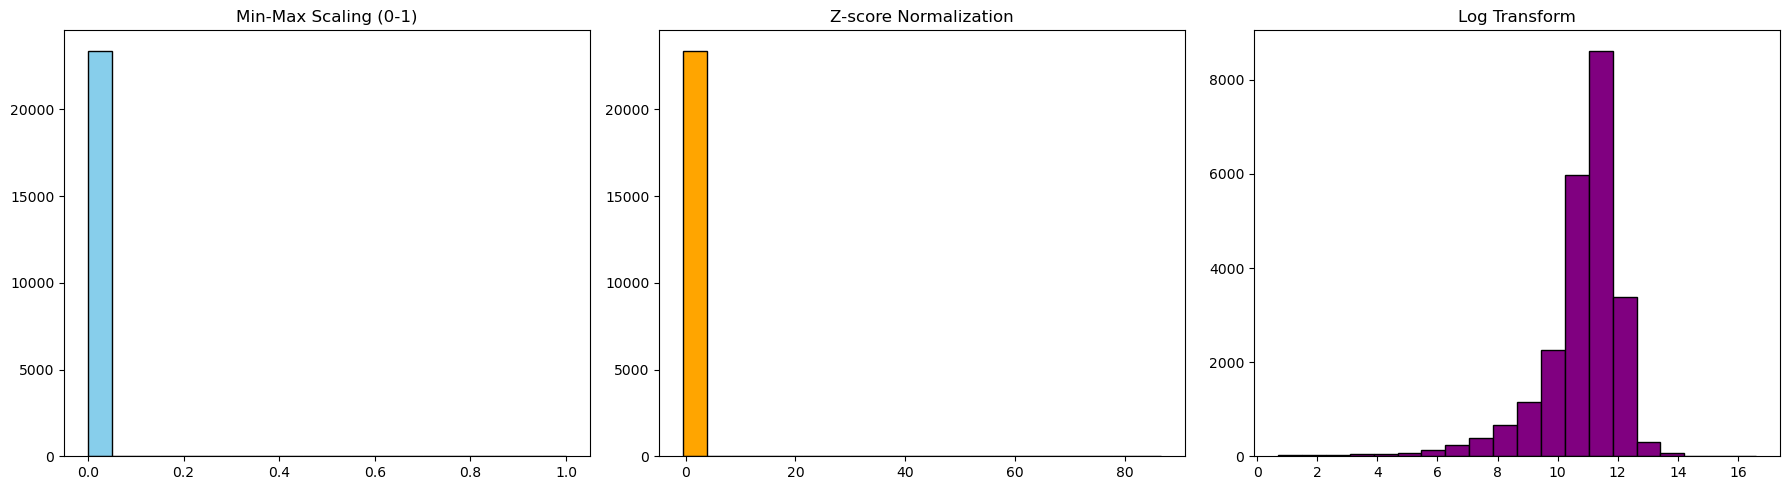

In [16]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].hist(minmax_values, bins=20, color='skyblue', edgecolor='black')
axes[0].set_title('Min-Max Scaling (0-1)')

axes[1].hist(zscore_values, bins=20, color='orange', edgecolor='black')
axes[1].set_title('Z-score Normalization')

axes[2].hist(log_values, bins=20, color='purple', edgecolor='black')
axes[2].set_title('Log Transform')

plt.tight_layout()
plt.show()

**Observation**: Min-Max and Z-score only rescale the values — the underlying shape is still
right-skewed, just like the original. The Log Transform, on the other hand, pulls the distribution
much closer to a normal shape, because `CompTotal` / `ConvertedCompYearly` contains some extremely
large values from multi-currency entries and outlier responses. The log-transformed version is the
more appropriate one to use for later visualization and statistical analysis.

## 6. Feature Engineering

### 6.1 Converting Years of Experience to a Number

`YearsCodePro` mixes text responses like "Less than 1 year" and "More than 50 years" with numeric
values, so I converted it to a usable numeric column:
- "Less than 1 year" → 0.5
- "More than 50 years" → 51

In [17]:
df['ExperienceLevel'] = df['YearsCodePro'].replace({
    'Less than 1 year': 0.5,
    'More than 50 years': 51
})
df['ExperienceLevel'] = pd.to_numeric(df['ExperienceLevel'], errors='coerce')
df['ExperienceLevel'].describe()

/var/folders/74/clmkmcd55lb37sjkh74s6b5m0000gn/T/ipykernel_6221/2776698185.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['ExperienceLevel'] = df['YearsCodePro'].replace({


count    65437.000000
mean         8.476794
std          8.732454
min          0.500000
25%          2.000000
50%          5.000000
75%         12.000000
max         51.000000
Name: ExperienceLevel, dtype: float64

### 6.2 Binning into Experience Ranges

The continuous `ExperienceLevel` column was binned into four ranges (0-5 / 5-10 / 10-20 / 20+ years)
to make comparisons across experience levels easier. This binned column is used again in the EDA
notebook to compare satisfaction and response distribution by experience group.

In [18]:
bins = [0, 5, 10, 20, np.inf]
labels = ['0-5', '5-10', '10-20', '>20']
df['Experience_Range'] = pd.cut(df['ExperienceLevel'], bins=bins, labels=labels, include_lowest=True)

df['Experience_Range'].value_counts().sort_index()

/var/folders/74/clmkmcd55lb37sjkh74s6b5m0000gn/T/ipykernel_6221/2762071370.py:3: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['Experience_Range'] = pd.cut(df['ExperienceLevel'], bins=bins, labels=labels, include_lowest=True)


Experience_Range
0-5      34324
5-10     12653
10-20    11625
>20       6835
Name: count, dtype: int64

### 6.3 Saving the Cleaned Data

Saving the cleaned dataset so the next notebook can pick up where this one left off.

In [19]:
df.to_csv('survey_data_cleaned.csv', index=False)
print(f"Final dataset shape: {df.shape}")

Final dataset shape: (65437, 117)


## Summary

What this notebook covered:

- Identified and removed only genuine duplicate rows, judged by `ResponseId`
- Applied different missing-value strategies depending on column type
  (categorical → mode, numeric → mean/median, columns with large country-level variance → per-group median)
- Flagged which `ConvertedCompYearly` rows were originally missing (`ConvertedCompYearly_was_missing`)
  before imputing, so later analysis can exclude the imputed rows when looking at the real distribution
  of reported compensation
- One-hot encoded the multi-select `Employment` column
- Compared Min-Max, Z-score, and Log transforms on the reported (non-imputed) compensation values, and
  concluded Log Transform is the most appropriate
- Converted text-based experience values into a numeric column and binned them into ranges

Next: [`02_eda_and_insights.ipynb`](./02_eda_and_insights.ipynb) — outlier detection, correlation
analysis, and a question I came up with myself.
